# Dışa Dönük ve İçe Dönük Davranış Tahmini

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTU2gHsRKSf9P0uzcOEqVDI3vej5mpWXgtRrQ&s">

Bu projede bireylerin sosyal davranış özellikleri kullanılarak kişilik tiplerinin (İçe Dönük – Introvert / Dışa Dönük – Extrovert) makine öğrenmesi yöntemleri ile tahmin edilmesi amaçlanmıştır. Kişinin yalnız geçirdiği süre, sosyal etkinliklere katılım düzeyi, arkadaş çevresi büyüklüğü, sahne korkusu ve sosyalleşme sonrası yorgunluk gibi davranışsal göstergeler analiz edilerek bir ikili sınıflandırma modeli geliştirilmiştir. Çalışma kapsamında veri keşif analizi (EDA), ön işleme adımları ve farklı sınıflandırma algoritmaları uygulanarak en başarılı model belirlenmeye çalışılmıştır.

### Sütun Açıklamaları

**Time_spent_Alone:**
Bireyin belirli bir zaman diliminde yalnız başına geçirdiği süreyi gösterir.

**Stage_fear:**
Bireyin kalabalık önünde konuşma veya performans sergileme konusunda korku yaşayıp yaşamadığını belirtir (Yes/No).

**Social_event_attendance:**
Bireyin sosyal etkinliklere katılım sıklığını sayısal olarak ifade eder.

**Going_outside:**
Bireyin dışarı çıkma ve sosyal ortamlarda bulunma sıklığını gösterir.

**Drained_after_socializing:**
Bireyin sosyalleştikten sonra kendini yorgun veya tükenmiş hissedip hissetmediğini belirtir (Yes/No).

**Friends_circle_size:**
Bireyin sahip olduğu aktif arkadaş çevresinin büyüklüğünü gösterir.

**Post_frequency:**
Bireyin sosyal medya veya benzeri platformlarda paylaşım yapma sıklığını ifade eder.

**Personality:**
Modelin tahmin etmeye çalıştığı hedef değişkendir ve bireyin kişilik tipini (Introvert veya Extrovert) gösterir.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/icedonuk/personality_datasert.csv


## Veri seti

https://www.kaggle.com/datasets/rakeshkapilavai/extrovert-vs-introvert-behavior-data/data

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import warnings
warnings.filterwarnings("ignore")


In [3]:
import pandas as pd

path = "/kaggle/input/icedonuk/personality_datasert.csv"

df = pd.read_csv(path)

df.head()


,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


In [4]:
df.columns


Index(['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance',
       'Going_outside', 'Drained_after_socializing', 'Friends_circle_size',
       'Post_frequency', 'Personality'],
      dtype='object')

In [5]:
df.shape

(2900, 8)

In [6]:
df.describe()

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,2900.000000,2900.000000,2900.000000,2900.000000,2900.000000
mean,4.505816,3.963354,3.000000,6.268863,3.564727
std,3.441180,2.872608,2.221597,4.232340,2.893587
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,1.000000,3.000000,1.000000
50%,4.000000,3.963354,3.000000,5.000000,3.000000
75%,7.000000,6.000000,5.000000,10.000000,6.000000
max,11.000000,10.000000,7.000000,15.000000,10.000000


In [7]:
df.corr(numeric_only=True)

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
Time_spent_Alone,1.000000,-0.718139,-0.735247,-0.701665,-0.718072
Social_event_attendance,-0.718139,1.000000,0.731941,0.718518,0.727732
Going_outside,-0.735247,0.731941,1.000000,0.718327,0.754758
Friends_circle_size,-0.701665,0.718518,0.718327,1.000000,0.690381
Post_frequency,-0.718072,0.727732,0.754758,0.690381,1.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2900 non-null   float64
 1   Stage_fear                 2900 non-null   object 
 2   Social_event_attendance    2900 non-null   float64
 3   Going_outside              2900 non-null   float64
 4   Drained_after_socializing  2900 non-null   object 
 5   Friends_circle_size        2900 non-null   float64
 6   Post_frequency             2900 non-null   float64
 7   Personality                2900 non-null   object 
dtypes: float64(5), object(3)
memory usage: 181.4+ KB


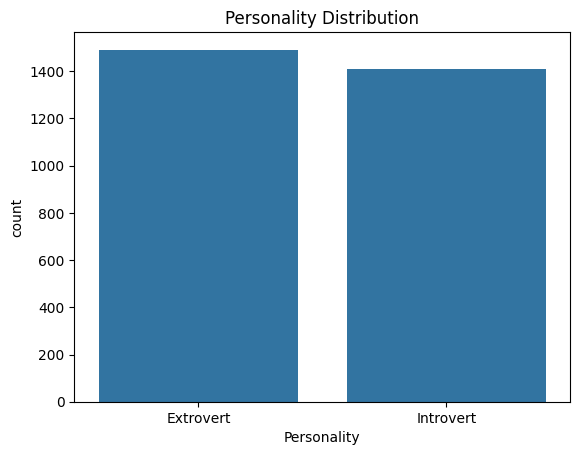

In [9]:
plt.figure()
sns.countplot(x="Personality", data=df)
plt.title("Personality Distribution")
plt.show()


Veri setinde extrovert ve introvert bireylerin sayıları birbirine oldukça yakın olup sınıflar dengeli dağılım göstermektedir.

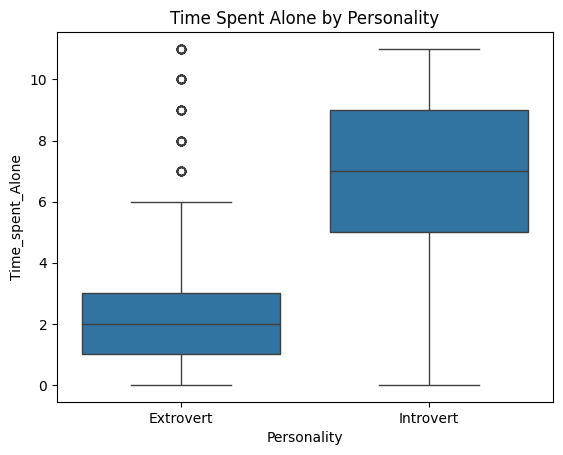

In [10]:
plt.figure()
sns.boxplot(x="Personality", y="Time_spent_Alone", data=df)
plt.title("Time Spent Alone by Personality")
plt.show()


Introvert bireylerin yalnız geçirdikleri süre extrovert bireylere göre belirgin şekilde daha yüksektir.

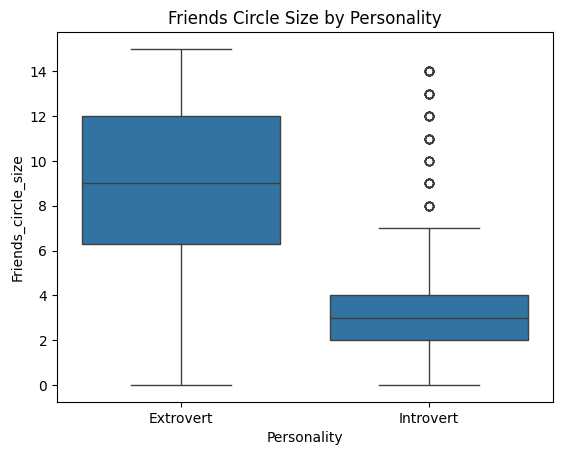

In [11]:
plt.figure()
sns.boxplot(x="Personality", y="Friends_circle_size", data=df)
plt.title("Friends Circle Size by Personality")
plt.show()


Extrovert bireylerin arkadaş çevresi büyüklüğü introvert bireylere kıyasla daha fazladır.

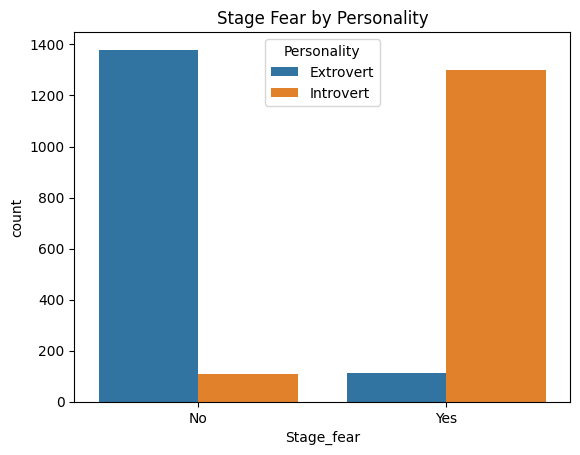

In [12]:
plt.figure()
sns.countplot(x="Stage_fear", hue="Personality", data=df)
plt.title("Stage Fear by Personality")
plt.show()


Sahne korkusu introvert bireylerde yüksek oranda görülürken extrovert bireylerde oldukça düşüktür.

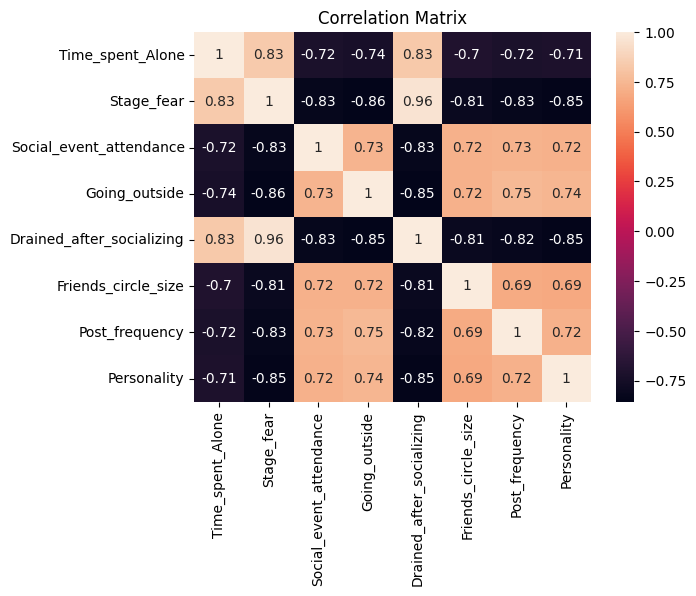

In [13]:
df_temp = df.copy()
df_temp["Personality"] = df_temp["Personality"].map({"Introvert":0, "Extrovert":1})
df_temp["Stage_fear"] = df_temp["Stage_fear"].map({"Yes":1, "No":0})
df_temp["Drained_after_socializing"] = df_temp["Drained_after_socializing"].map({"Yes":1, "No":0})

plt.figure()
sns.heatmap(df_temp.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()


Kişilik değişkeni; yalnız geçirilen süre, sahne korkusu ve sosyalleşme sonrası yorgunluk ile negatif; sosyal etkinlik katılımı, dışarı çıkma sıklığı ve arkadaş çevresi büyüklüğü ile pozitif güçlü ilişki göstermektedir. 
(Introvert → 0
Extrovert → 1 
Pozitif korelasyon = Extrovert olma eğilimi artıyor. Negatif korelasyon = Introvert olma eğilimi artıyor)

In [14]:
x = df_temp.drop("Personality", axis=1)
y = df_temp["Personality"]


In [15]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)


In [16]:
from sklearn.naive_bayes import GaussianNB # Bütün özelliklerin birbirinden bağımsız olduğunu kabul eder.
# çoğu kişi ortalama civarındadır, çok düşük ve çok yüksek değerler daha az görülür.
g = GaussianNB()

model1 = g.fit(x_train, y_train)
tahmin1 = model1.predict(x_test)

print("GaussianNB Accuracy:", accuracy_score(y_test, tahmin1))
#Bu projede içe dönük ve dışa dönük bireylerin davranış özellikleri birbirinden belirgin şekilde farklı olduğu için model yaklaşık %93 doğruluk oranına ulaştı.

GaussianNB Accuracy: 0.9293103448275862


In [17]:
print(classification_report(y_test, tahmin1))

              precision    recall  f1-score   support

           0       0.92      0.94      0.93       278
           1       0.94      0.92      0.93       302

    accuracy                           0.93       580
   macro avg       0.93      0.93      0.93       580
weighted avg       0.93      0.93      0.93       580



In [18]:
from sklearn.linear_model import LogisticRegression #Özellikleri ağırlıklandırır.

lr = LogisticRegression()

model2 = lr.fit(x_train, y_train)
tahmin2 = model2.predict(x_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, tahmin2))


Logistic Regression Accuracy: 0.9241379310344827


In [19]:
print(classification_report(y_test, tahmin2))

              precision    recall  f1-score   support

           0       0.91      0.93      0.92       278
           1       0.93      0.92      0.93       302

    accuracy                           0.92       580
   macro avg       0.92      0.92      0.92       580
weighted avg       0.92      0.92      0.92       580



In [20]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

model3 = knn.fit(x_train, y_train)
tahmin3 = model3.predict(x_test)

print("KNN Accuracy:", accuracy_score(y_test, tahmin3))


KNN Accuracy: 0.9224137931034483


In [21]:
print(classification_report(y_test, tahmin3))

              precision    recall  f1-score   support

           0       0.91      0.93      0.92       278
           1       0.93      0.92      0.92       302

    accuracy                           0.92       580
   macro avg       0.92      0.92      0.92       580
weighted avg       0.92      0.92      0.92       580



In [22]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

model4 = dt.fit(x_train, y_train)
tahmin4 = model4.predict(x_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, tahmin4))


Decision Tree Accuracy: 0.8862068965517241


In [23]:
print(classification_report(y_test, tahmin4))

              precision    recall  f1-score   support

           0       0.87      0.90      0.88       278
           1       0.91      0.87      0.89       302

    accuracy                           0.89       580
   macro avg       0.89      0.89      0.89       580
weighted avg       0.89      0.89      0.89       580



In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

model5 = rf.fit(x_train, y_train)
tahmin5 = model5.predict(x_test)

print("Random Forest Accuracy:", accuracy_score(y_test, tahmin5))


Random Forest Accuracy: 0.9189655172413793


In [25]:
print(classification_report(y_test, tahmin5))

              precision    recall  f1-score   support

           0       0.91      0.92      0.92       278
           1       0.93      0.92      0.92       302

    accuracy                           0.92       580
   macro avg       0.92      0.92      0.92       580
weighted avg       0.92      0.92      0.92       580



In [26]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()

model6 = gb.fit(x_train, y_train)
tahmin6 = model6.predict(x_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, tahmin6))


Gradient Boosting Accuracy: 0.9293103448275862


In [27]:
print(classification_report(y_test, tahmin6))

              precision    recall  f1-score   support

           0       0.92      0.94      0.93       278
           1       0.94      0.92      0.93       302

    accuracy                           0.93       580
   macro avg       0.93      0.93      0.93       580
weighted avg       0.93      0.93      0.93       580



Confusion Matrix:
 [[261  17]
 [ 24 278]]


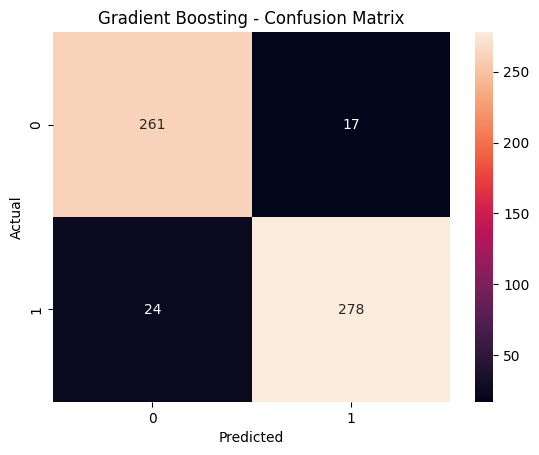

In [28]:

cm = confusion_matrix(y_test, tahmin6)

print("Confusion Matrix:\n", cm)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Gradient Boosting - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


0: introvert
1: extrovert

261: Gerçek Introvert olan kişiler doğru şekilde Introvert tahmin edilmiştir.
17: Gerçek Introvert olan kişiler yanlışlıkla Extrovert tahmin edilmiştir.
24: Gerçek Extrovert olan kişiler yanlışlıkla Introvert tahmin edilmiştir.
278: Gerçek Extrovert olan kişiler doğru şekilde Extrovert tahmin edilmiştir.


 TP (True Positive) = 278
Gerçek Extrovert, model de Extrovert dedi.
TN (True Negative) = 261
Gerçek Introvert, model de Introvert dedi.
FP (False Positive) = 17
Gerçek Introvert, model yanlışlıkla Extrovert dedi.
 FN (False Negative) = 24
Gerçek Extrovert, model yanlışlıkla Introvert dedi.

In [29]:
from sklearn.ensemble import ExtraTreesClassifier

etr = ExtraTreesClassifier()

model7 = etr.fit(x_train, y_train)
tahmin7 = model7.predict(x_test)

print("Extra Trees Accuracy:", accuracy_score(y_test, tahmin7))



Extra Trees Accuracy: 0.9241379310344827


In [30]:
print(classification_report(y_test, tahmin7))

              precision    recall  f1-score   support

           0       0.91      0.93      0.92       278
           1       0.94      0.92      0.93       302

    accuracy                           0.92       580
   macro avg       0.92      0.92      0.92       580
weighted avg       0.92      0.92      0.92       580



In [31]:
from sklearn.svm import SVC

svm = SVC()

model8 = svm.fit(x_train, y_train)
tahmin8 = model8.predict(x_test)

print("SVM Accuracy:", accuracy_score(y_test, tahmin8))
print(classification_report(y_test, tahmin8))


SVM Accuracy: 0.9293103448275862
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       278
           1       0.94      0.92      0.93       302

    accuracy                           0.93       580
   macro avg       0.93      0.93      0.93       580
weighted avg       0.93      0.93      0.93       580



In [32]:
# Gaussian Naive Bayes: Olasılık hesabı yaparak sınıflandırır.
print("GaussianNB Accuracy:", accuracy_score(y_test, tahmin1))

# Logistic Regression: Özelliklere ağırlık vererek olasılık hesaplar ve sınıflandırır.
print("Logistic Regression Accuracy:", accuracy_score(y_test, tahmin2))

# KNN: En yakın K komşusunun çoğunluğuna göre sınıflandırma yapar.
print("KNN Accuracy:", accuracy_score(y_test, tahmin3))

# Decision Tree: Veriyi kurallara göre dallandırarak karar verir.
print("Decision Tree Accuracy:", accuracy_score(y_test, tahmin4))

# Random Forest: Birden fazla karar ağacının oyunu ile tahmin yapar.
print("Random Forest Accuracy:", accuracy_score(y_test, tahmin5))

# Gradient Boosting: Önceki modellerin hatalarını düzelterek öğrenir.
print("Gradient Boosting Accuracy:", accuracy_score(y_test, tahmin6))

# Extra Trees: Rastgele oluşturulan birçok karar ağacının oyuyla tahmin yapar.
print("Extra Trees Accuracy:", accuracy_score(y_test, tahmin7))

# SVM: Sınıfları ayıran en iyi karar sınırını (hiperdüzlemi) bulur.
print("SVM Accuracy:", accuracy_score(y_test, tahmin8))

GaussianNB Accuracy: 0.9293103448275862
Logistic Regression Accuracy: 0.9241379310344827
KNN Accuracy: 0.9224137931034483
Decision Tree Accuracy: 0.8862068965517241
Random Forest Accuracy: 0.9189655172413793
Gradient Boosting Accuracy: 0.9293103448275862
Extra Trees Accuracy: 0.9241379310344827
SVM Accuracy: 0.9293103448275862


**Yorumlama**

GaussianNB gibi basit bir modelin bile bu kadar yüksek başarı göstermesi,
verinin sınıflar arasında oldukça net ayrıştığını gösterir.

Decision Tree’in daha düşük çıkması,
tek ağaç yapısının overfitting yapmış olabileceğini düşündürür.

Ağaç tabanlı gelişmiş modeller (Gradient Boosting, Extra Trees) gayet başarılı.

Accuracy değerleri birbirine çok yakın olduğu için,
burada artık:

Confusion matrix

Precision / Recall

F1-score
gibi metriklere bakmak daha anlamlı olur.

-> Precision
Modelin “pozitif” dediği örneklerin gerçekten pozitif olma oranı.
Yanlış alarmı ölçer.

-> Recall
Gerçek pozitiflerin ne kadarını yakaladığını gösterir.
Kaçırma oranını ölçer.

Peki F1 Ne İşe Yarar?

-> F1-score:
Hem yanlış alarmı hem de kaçırma hatasını aynı anda ölçer.

Yani:
Sadece precision yüksek olsun yetmez
Sadece recall yüksek olsun yetmez
İkisi dengeli olsun ister

Kısaca
F1-score modelin dengeli ve güvenilir performans gösterip göstermediğini ölçer.

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
import pandas as pd


def algo_test_classification(x, y):
    
    # Modeller
    LR  = LogisticRegression(max_iter=1000)
    NB  = GaussianNB()
    GB  = GradientBoostingClassifier()
    ET  = ExtraTreesClassifier()
    KNN = KNeighborsClassifier()
    DT  = DecisionTreeClassifier()
    SVM = SVC()
    
    algos = [LR, NB, GB, ET, KNN, DT, SVM]
    
    algo_names = [
        'Logistic Regression',
        'Naive Bayes',
        'Gradient Boosting',
        'Extra Trees',
        'KNN',
        'Decision Tree',
        'SVM'
    ]
    
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.2, random_state=42
    )
    
    accuracy = []
    f1 = []
    
    result = pd.DataFrame(columns=['Accuracy', 'F1_Score'], index=algo_names)
    
    for algo in algos:
        p = algo.fit(x_train, y_train).predict(x_test)
        
        accuracy.append(accuracy_score(y_test, p))
        f1.append(f1_score(y_test, p))
    
    result['Accuracy'] = accuracy
    result['F1_Score'] = f1
    
    return result.sort_values('Accuracy', ascending=False)


In [34]:
algo_test_classification(x, y)


,Accuracy,F1_Score
Naive Bayes,0.929310,0.931323
Gradient Boosting,0.929310,0.931323
SVM,0.929310,0.931323
Logistic Regression,0.924138,0.926667
Extra Trees,0.924138,0.926421
KNN,0.922414,0.924875
Decision Tree,0.882759,0.885522


## Sonuç

Bu çalışmada farklı makine öğrenmesi algoritmaları karşılaştırılmış olup en yüksek başarı oranı yaklaşık %92.9 ile Gaussian Naive Bayes, Gradient Boosting ve SVM modelleri tarafından elde edilmiştir. Modeller arasındaki performans farklarının düşük olması, veri setindeki sınıfların belirgin özelliklerle ayrıştığını göstermektedir.